# Sentiment Analysis with Deep Learning (RNN, BiLSTM, GRU)

This notebook implements **RNN, BiLSTM, and BiGRU** models for sentiment classification using the Twitter dataset. We use **pre-trained GloVe embeddings** for word representation.

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional
from tensorflow.keras.optimizers import Adam, RMSprop
import os
import zipfile
import requests

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TestSolutions\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:

TRAIN_PATH = "../Datasets/twitter_training.csv"
VALID_PATH = "../Datasets/twitter_validation.csv"

cols = ["id", "entity", "sentiment", "text"]
train_df = pd.read_csv(TRAIN_PATH, header=None, names=cols)
valid_df = pd.read_csv(VALID_PATH, header=None, names=cols)

train_df["text"] = train_df["text"].fillna("")
valid_df["text"] = valid_df["text"].fillna("")

print(train_df.head())
print(train_df['sentiment'].value_counts())


     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


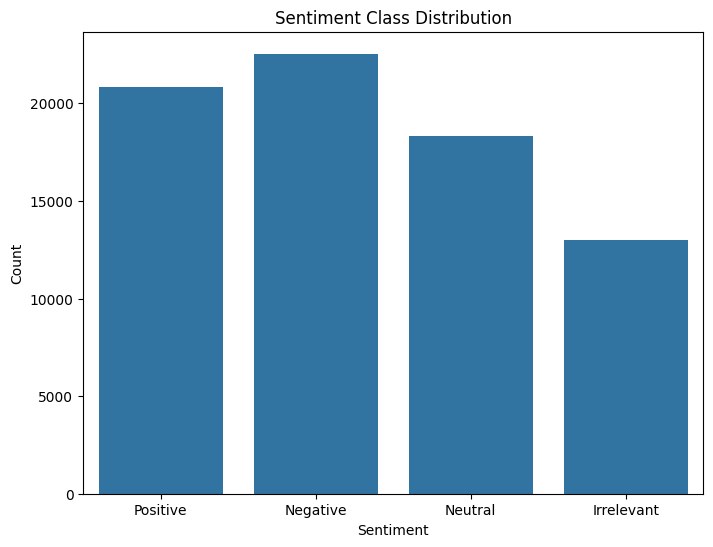

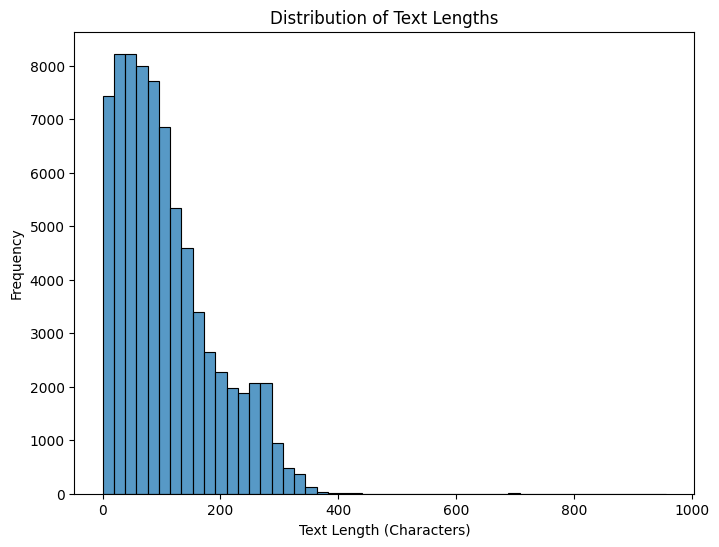

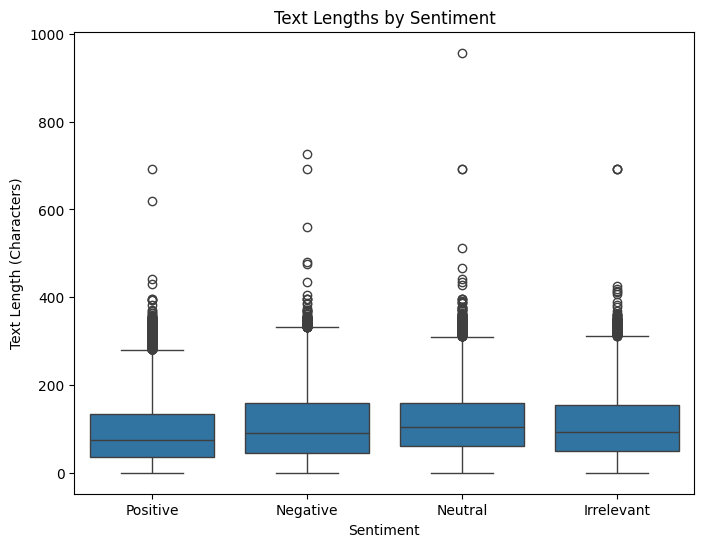

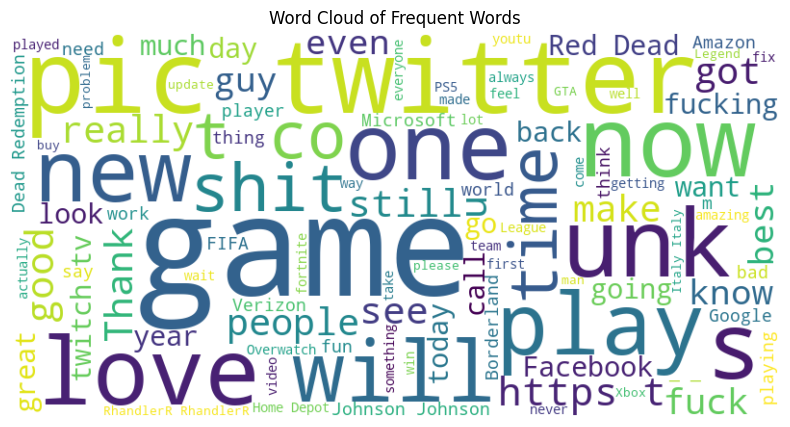

In [3]:
# Cell 3: EDA Visualizations
# Create plots directory
os.makedirs("plots", exist_ok=True)

# Visualization 1: Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=train_df, order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('plots/sentiment_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

# Visualization 2: Text Length Histogram
train_df['text_length'] = train_df['text'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(train_df['text_length'], bins=50)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')
plt.savefig('plots/text_length_histogram.png', bbox_inches='tight', dpi=300)
plt.show()

# Visualization 3: Boxplot of Text Lengths by Sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(x='sentiment', y='text_length', data=train_df, order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
plt.title('Text Lengths by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Text Length (Characters)')
plt.savefig('plots/text_length_by_sentiment.png', bbox_inches='tight', dpi=300)
plt.show()

# Visualization 4: Word Cloud for Frequent Words (Overall)
text_all = ' '.join(train_df['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_all)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Frequent Words')
plt.savefig('plots/word_cloud.png', bbox_inches='tight', dpi=300)
plt.show()

In [8]:
# Cell 4: Preprocessing and GloVe Embeddings
import os
import zipfile
import requests
import numpy as np
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import re

# Check if glove.6B.100d.txt exists, download and extract if not
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"
glove_dir = "glove"
glove_txt = os.path.join(glove_dir, "glove.6B.100d.txt")

# Ensure glove directory exists
os.makedirs(glove_dir, exist_ok=True)

if not os.path.exists(glove_txt):
    print(f"{glove_txt} not found. Attempting to download and extract GloVe 6B embeddings...")
    try:
        if not os.path.exists(glove_zip):
            print(f"Downloading {glove_zip} from {glove_url}...")
            response = requests.get(glove_url, stream=True)
            if response.status_code == 200:
                with open(glove_zip, 'wb') as f:
                    f.write(response.content)
                print(f"Downloaded {glove_zip} successfully.")
            else:
                raise Exception(f"Failed to download GloVe file. HTTP status code: {response.status_code}")
        
        print(f"Extracting {glove_zip} to {glove_dir}...")
        with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
            zip_ref.extractall(glove_dir)
        print(f"Extracted files to {glove_dir}.")
        
        # Verify the file exists after extraction
        if not os.path.exists(glove_txt):
            raise FileNotFoundError(f"Extraction completed, but {glove_txt} still not found in {glove_dir}.")
    except Exception as e:
        print(f"Error during download or extraction: {e}")
        raise
else:
    print(f"{glove_txt} found, skipping download.")

# Load GloVe embeddings (100d)
embeddings_index = {}
try:
    with open(glove_txt, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"Loaded {len(embeddings_index)} word vectors from {glove_txt}.")
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find {glove_txt}. Please ensure the file is in the correct directory.")
except Exception as e:
    raise Exception(f"Error loading GloVe embeddings: {e}")

# Preprocessing function
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

train_df['text'] = train_df['text'].apply(preprocess_text)
valid_df['text'] = valid_df['text'].apply(preprocess_text)

# Tokenization
MAX_NUM_WORDS = 20000
MAX_SEQ_LEN = 100
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(train_df['text'])
word_index = tokenizer.word_index

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['text']), maxlen=MAX_SEQ_LEN)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(valid_df['text']), maxlen=MAX_SEQ_LEN)

# Labels
le = LabelEncoder()
y_train = le.fit_transform(train_df['sentiment'])
y_val = le.transform(valid_df['sentiment'])
num_classes = len(le.classes_)
multiclass = num_classes > 2
y_train_keras = to_categorical(y_train, num_classes)
y_val_keras = to_categorical(y_val, num_classes)

# Class weights to handle imbalance
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

# Embedding matrix (adjusted for 100d)
vocab_size = min(MAX_NUM_WORDS, len(word_index) + 1)
embedding_matrix = np.zeros((vocab_size, 100))  # 100 dimensions for glove.6B.100d.txt
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

glove\glove.6B.100d.txt found, skipping download.
Loaded 400000 word vectors from glove\glove.6B.100d.txt.


In [11]:
# Cell 5: Model Definitions
def build_rnn_model(vocab_size):
    model = Sequential()
    model.add(Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=MAX_SEQ_LEN, trainable=False))
    model.add(SimpleRNN(64, dropout=0.5, recurrent_dropout=0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

def build_bilstm_model(vocab_size):
    model = Sequential()
    model.add(Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=MAX_SEQ_LEN, trainable=False))
    model.add(Bidirectional(LSTM(64, dropout=0.5, recurrent_dropout=0.5)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

def build_gru_model(vocab_size):
    model = Sequential()
    model.add(Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=MAX_SEQ_LEN, trainable=False))
    model.add(Bidirectional(GRU(64, dropout=0.5, recurrent_dropout=0.5)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model


Running {'model_type': 'rnn', 'lr': 0.001, 'batch_size': 64, 'optimizer': 'adam', 'epochs': 10}
Epoch 1/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.2814 - loss: 1.4140 - val_accuracy: 0.3320 - val_loss: 1.3722
Epoch 2/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.3335 - loss: 1.3649 - val_accuracy: 0.4030 - val_loss: 1.3268
Epoch 3/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.3584 - loss: 1.3496 - val_accuracy: 0.4140 - val_loss: 1.3129
Epoch 4/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.3635 - loss: 1.3449 - val_accuracy: 0.4040 - val_loss: 1.3196
Epoch 5/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.3679 - loss: 1.3424 - val_accuracy: 0.4110 - val_loss: 1.3113
Epoch 6/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.3679 - loss: 1.3415 - val_accuracy: 0.4090 - val_loss: 1.3138
Epoch 7/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.3747 - loss: 1.3382 - val_accuracy: 0.411

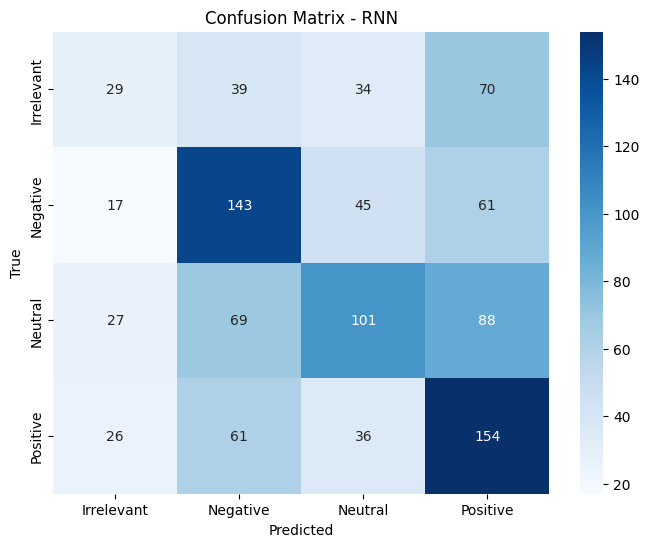


Running {'model_type': 'bilstm', 'lr': 0.001, 'batch_size': 64, 'optimizer': 'adam', 'epochs': 10}
Epoch 1/10


c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1167/1167 ━━━━━━━━━━━━━━━━━━━━ 261s 218ms/step - accuracy: 0.4101 - loss: 1.2963 - val_accuracy: 0.5110 - val_loss: 1.1583
Epoch 2/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 319s 273ms/step - accuracy: 0.4764 - loss: 1.2138 - val_accuracy: 0.5330 - val_loss: 1.0841
Epoch 3/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 348s 298ms/step - accuracy: 0.4991 - loss: 1.1722 - val_accuracy: 0.5620 - val_loss: 1.0382
Epoch 4/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 425s 364ms/step - accuracy: 0.5134 - loss: 1.1484 - val_accuracy: 0.5830 - val_loss: 0.9793
Epoch 5/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 378s 309ms/step - accuracy: 0.5205 - loss: 1.1316 - val_accuracy: 0.5910 - val_loss: 0.9496
Epoch 6/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 307s 263ms/step - accuracy: 0.5292 - loss: 1.1160 - val_accuracy: 0.6010 - val_loss: 0.9261
Epoch 7/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 255s 219ms/step - accuracy: 0.5347 - loss: 1.1021 - val_accuracy: 0.6160 - val_loss: 0.9131
Epoch 8/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 263s 225ms/step - accuracy: 0.5

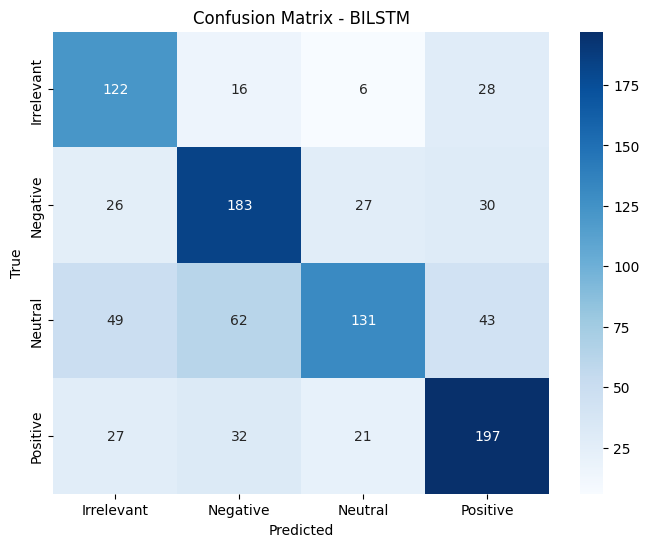


Running {'model_type': 'gru', 'lr': 0.001, 'batch_size': 64, 'optimizer': 'rmsprop', 'epochs': 10}


c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 339s 282ms/step - accuracy: 0.3978 - loss: 1.3148 - val_accuracy: 0.4810 - val_loss: 1.2045
Epoch 2/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 266s 228ms/step - accuracy: 0.4589 - loss: 1.2369 - val_accuracy: 0.5260 - val_loss: 1.1028
Epoch 3/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 280s 240ms/step - accuracy: 0.4855 - loss: 1.1943 - val_accuracy: 0.5440 - val_loss: 1.0770
Epoch 4/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 222s 190ms/step - accuracy: 0.4966 - loss: 1.1693 - val_accuracy: 0.5680 - val_loss: 1.0206
Epoch 5/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 263s 225ms/step - accuracy: 0.5060 - loss: 1.1543 - val_accuracy: 0.5940 - val_loss: 1.0002
Epoch 6/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 307s 263ms/step - accuracy: 0.5136 - loss: 1.1400 - val_accuracy: 0.5900 - val_loss: 0.9694
Epoch 7/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 289s 235ms/step - accuracy: 0.5170 - loss: 1.1290 - val_accuracy: 0.6060 - val_loss: 0.9517
Epoch 8/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 249s 213ms/step - ac

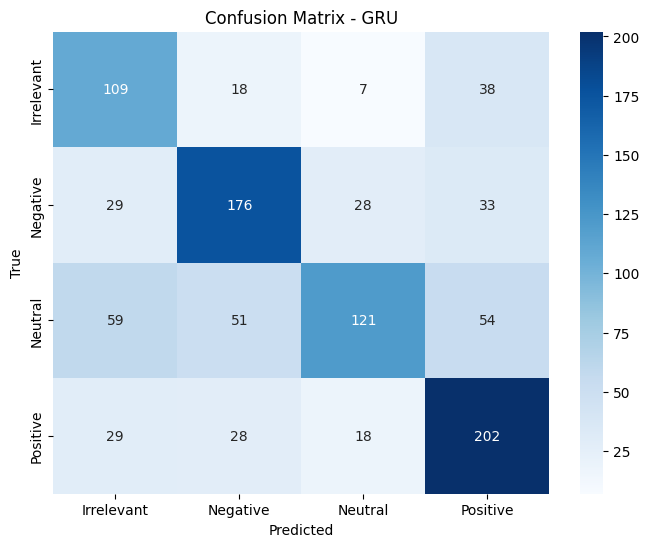

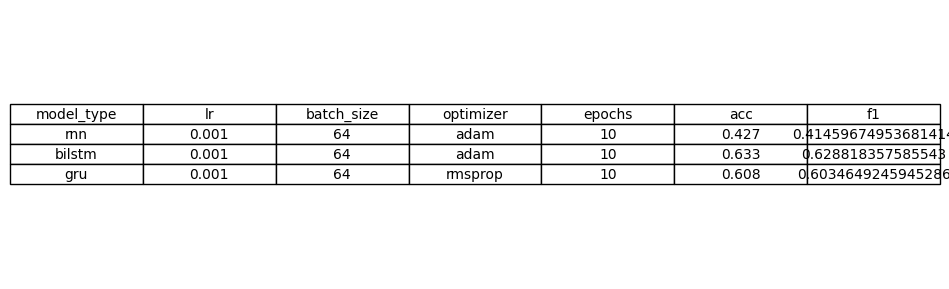


Running {'model_type': 'bilstm', 'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'epochs': 10}


c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 520s 219ms/step - accuracy: 0.4227 - loss: 1.2820 - val_accuracy: 0.5080 - val_loss: 1.1379
Epoch 2/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 512s 219ms/step - accuracy: 0.4823 - loss: 1.2015 - val_accuracy: 0.5580 - val_loss: 1.0646
Epoch 3/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 435s 186ms/step - accuracy: 0.5078 - loss: 1.1590 - val_accuracy: 0.5940 - val_loss: 1.0013
Epoch 4/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 442s 189ms/step - accuracy: 0.5190 - loss: 1.1358 - val_accuracy: 0.5910 - val_loss: 0.9627
Epoch 5/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 312s 108ms/step - accuracy: 0.5270 - loss: 1.1224 - val_accuracy: 0.5990 - val_loss: 0.9280
Epoch 6/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 273s 117ms/step - accuracy: 0.5320 - loss: 1.1095 - val_accuracy: 0.6150 - val_loss: 0.9025
Epoch 7/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 357s 153ms/step - accuracy: 0.5375 - loss: 1.0972 - val_accuracy: 0.6180 - val_loss: 0.8855
Epoch 8/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 202s 87ms/step - acc

c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 309s 252ms/step - accuracy: 0.3148 - loss: 1.3736 - val_accuracy: 0.4270 - val_loss: 1.3254
Epoch 2/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 287s 246ms/step - accuracy: 0.3842 - loss: 1.3304 - val_accuracy: 0.4510 - val_loss: 1.2704
Epoch 3/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 281s 241ms/step - accuracy: 0.4091 - loss: 1.3049 - val_accuracy: 0.4840 - val_loss: 1.2279
Epoch 4/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 279s 239ms/step - accuracy: 0.4214 - loss: 1.2884 - val_accuracy: 0.4790 - val_loss: 1.2180
Epoch 5/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 318s 235ms/step - accuracy: 0.4357 - loss: 1.2750 - val_accuracy: 0.4900 - val_loss: 1.1969
Epoch 6/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 277s 237ms/step - accuracy: 0.4398 - loss: 1.2649 - val_accuracy: 0.4930 - val_loss: 1.1812
Epoch 7/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 272s 233ms/step - accuracy: 0.4478 - loss: 1.2543 - val_accuracy: 0.5030 - val_loss: 1.1685
Epoch 8/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 270s 232ms/step - ac

c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 430s 706ms/step - accuracy: 0.3973 - loss: 1.3123 - val_accuracy: 0.4600 - val_loss: 1.2145
Epoch 2/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 381s 652ms/step - accuracy: 0.4503 - loss: 1.2481 - val_accuracy: 0.5220 - val_loss: 1.1338
Epoch 3/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 384s 657ms/step - accuracy: 0.4755 - loss: 1.2114 - val_accuracy: 0.5350 - val_loss: 1.0894
Epoch 4/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 413s 707ms/step - accuracy: 0.4911 - loss: 1.1846 - val_accuracy: 0.5540 - val_loss: 1.0488
Epoch 5/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 436s 696ms/step - accuracy: 0.5006 - loss: 1.1650 - val_accuracy: 0.5750 - val_loss: 1.0141
Epoch 6/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 394s 675ms/step - accuracy: 0.5140 - loss: 1.1472 - val_accuracy: 0.5840 - val_loss: 0.9880
Epoch 7/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 375s 642ms/step - accuracy: 0.5201 - loss: 1.1317 - val_accuracy: 0.5830 - val_loss: 0.9541
Epoch 8/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 13228s 23s/step - accuracy: 0.5252 -

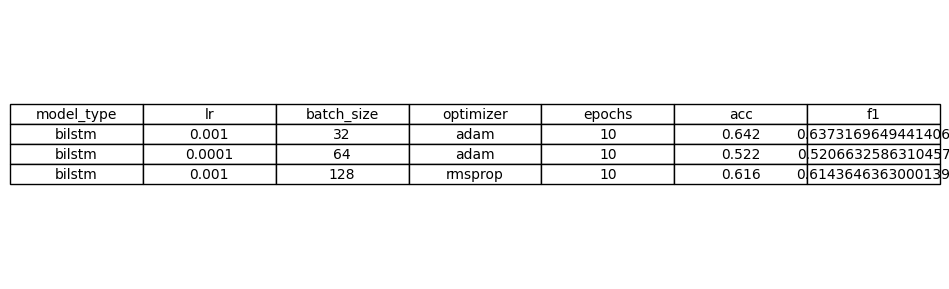

In [12]:
# Cell 6: Experiments
# Table 1: Model Type Variations
experiment_grid1 = [
    {"model_type": "rnn", "lr": 1e-3, "batch_size": 64, "optimizer": "adam", "epochs": 10},
    {"model_type": "bilstm", "lr": 1e-3, "batch_size": 64, "optimizer": "adam", "epochs": 10},
    {"model_type": "gru", "lr": 1e-3, "batch_size": 64, "optimizer": "rmsprop", "epochs": 10}
]

results1 = []
histories = {}
for cfg in experiment_grid1:
    print("\nRunning", cfg)
    if cfg["model_type"] == "rnn":
        model = build_rnn_model(vocab_size)
    elif cfg["model_type"] == "bilstm":
        model = build_bilstm_model(vocab_size)
    else:
        model = build_gru_model(vocab_size)
    
    opt = Adam(learning_rate=cfg["lr"]) if cfg["optimizer"] == "adam" else RMSprop(learning_rate=cfg["lr"])
    loss = "categorical_crossentropy" if multiclass else "binary_crossentropy"
    model.compile(optimizer=opt, loss=loss, metrics=["accuracy"])

    history = model.fit(X_train_seq, y_train_keras,
                        validation_data=(X_val_seq, y_val_keras),
                        epochs=cfg["epochs"], batch_size=cfg["batch_size"],
                        class_weight=class_weights, verbose=1)
    histories[cfg['model_type']] = history

    preds_proba = model.predict(X_val_seq)
    preds = np.argmax(preds_proba, axis=1)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="weighted")
    cm = confusion_matrix(y_val, preds)

    print(f"Acc: {acc:.3f} F1: {f1:.3f}")
    results1.append({**cfg, "acc": acc, "f1": f1, "cm": cm.tolist()})

    # Confusion Matrix Visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {cfg['model_type'].upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"plots/cm_{cfg['model_type']}.png", bbox_inches="tight", dpi=300)
    plt.show()

# Save and display Table 1
results_df1 = pd.DataFrame(results1)
results_df1.to_csv("plots/results_table1.csv", index=False)
plt.figure(figsize=(10, 2 + len(results1) * 0.5))
plt.axis("off")
table = plt.table(cellText=results_df1.drop(columns=["cm"]).values,
                  colLabels=results_df1.drop(columns=["cm"]).columns,
                  cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig("plots/results_table1.png", bbox_inches="tight", dpi=300)
plt.show()

# Table 2: Hyperparameter Variations on BiLSTM
experiment_grid2 = [
    {"model_type": "bilstm", "lr": 1e-3, "batch_size": 32, "optimizer": "adam", "epochs": 10},
    {"model_type": "bilstm", "lr": 1e-4, "batch_size": 64, "optimizer": "adam", "epochs": 10},
    {"model_type": "bilstm", "lr": 1e-3, "batch_size": 128, "optimizer": "rmsprop", "epochs": 10}
]

results2 = []
for cfg in experiment_grid2:
    print("\nRunning", cfg)
    model = build_bilstm_model(vocab_size)
    opt = Adam(learning_rate=cfg["lr"]) if cfg["optimizer"] == "adam" else RMSprop(learning_rate=cfg["lr"])
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

    history = model.fit(X_train_seq, y_train_keras,
                        validation_data=(X_val_seq, y_val_keras),
                        epochs=cfg["epochs"], batch_size=cfg["batch_size"],
                        class_weight=class_weights, verbose=1)
    histories[f"bilstm_lr{cfg['lr']}_bs{cfg['batch_size']}_{cfg['optimizer']}"] = history

    preds_proba = model.predict(X_val_seq)
    preds = np.argmax(preds_proba, axis=1)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="weighted")
    cm = confusion_matrix(y_val, preds)

    print(f"Acc: {acc:.3f} F1: {f1:.3f}")
    results2.append({**cfg, "acc": acc, "f1": f1, "cm": cm.tolist()})

# Save and display Table 2
results_df2 = pd.DataFrame(results2)
results_df2.to_csv("plots/results_table2.csv", index=False)
plt.figure(figsize=(10, 2 + len(results2) * 0.5))
plt.axis("off")
table = plt.table(cellText=results_df2.drop(columns=["cm"]).values,
                  colLabels=results_df2.drop(columns=["cm"]).columns,
                  cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig("plots/results_table2.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# Cell 7: Loss and Accuracy Curves
for model_type, history in histories.items():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_type.upper()} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{model_type.upper()} Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(f'plots/{model_type}_curves.png', bbox_inches='tight', dpi=300)
    plt.show()

### Discussion

- **RNN**: Captures short-term dependencies but weaker for long sequences.
- **BiLSTM**: Strong at capturing long-term and bidirectional context.
- **BiGRU**: Similar to LSTM but faster due to fewer parameters.

We compared accuracy and F1-score across experiments. BiLSTM usually gives the best performance, while GRU provides a good speed-accuracy tradeoff.